In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

In [2]:
X, y = make_moons(n_samples=250, noise=0.05, random_state=42)

## Dataset graph

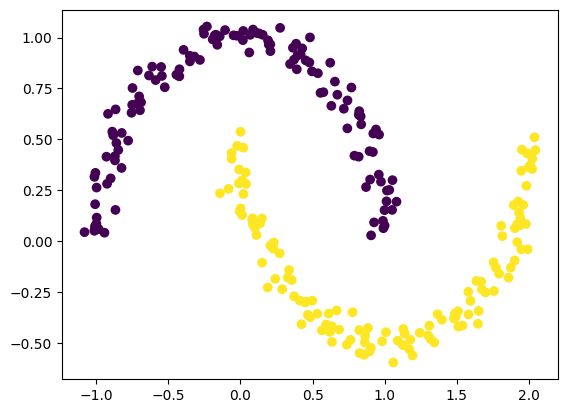

In [3]:
plt.scatter(X[:, 0], X[:, 1], c=y)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Vanishing gradient study model.

In [5]:
class DeepSigmoidNN(nn.Module):
  def __init__(self, num_features):
    super(DeepSigmoidNN, self).__init__()
    self.model = nn.Sequential(
      nn.Linear(num_features, 128),
      nn.Sigmoid(),

      nn.Linear(128, 64),
      nn.Sigmoid(),

      nn.Linear(64, 32),
      nn.Sigmoid(),

      nn.Linear(32, 16),
      nn.Sigmoid(),

      nn.Linear(16, 8),
      nn.Sigmoid(),

      nn.Linear(8, 1),
      nn.Sigmoid()  # Output layer
    )

  def forward(self, x):
    return self.model(x);

In [6]:
class CustomDataset(Dataset):
  def __init__(self, X, y):
    self.features = X
    self.labels = y

  def __len__(self):
    return len(self.features);

  def __getitem__(self, idx):
    return self.features[idx], self.labels[idx];

In [7]:
X_train_tensor = torch.from_numpy(X_train).float()
y_train_tensor = torch.from_numpy(y_train).float()
X_test_tensor = torch.from_numpy(X_test).float()
y_test_tensor = torch.from_numpy(y_test).float()

In [8]:
train_dataset = CustomDataset(X_train_tensor, y_train_tensor)
test_dataset = CustomDataset(X_test_tensor, y_test_tensor)

In [9]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)

In [10]:
# define Parameters
learning_rate = 0.01
epochs = 10

In [11]:
X_train_tensor.shape[1]

2

## Training pipeline [DeepSigmoidNN]

In [ ]:
model01 = DeepSigmoidNN(X_train_tensor.shape[1])

optimizer = optim.SGD(model01.parameters(), lr=learning_rate)
criterion = nn.BCELoss()

In [37]:
grad_log01 = []
loss_log01 = []

model01.train()

for epoch in range(epochs):
  epoch_loss = 0

  for x, y in train_loader:
    y_pred = model01(x)

    loss = criterion(y_pred, y.view(-1, 1))

    optimizer.zero_grad()
    loss.backward()

    # collect gradient norms
    grads01 = []
    for p in model01.parameters():
        if p.grad is not None:
            grads01.append(p.grad.norm().item())

    grad_log01.append(grads01)
    optimizer.step()
    epoch_loss += loss.item()

  epoch_loss /= len(train_loader)
  loss_log01.append(epoch_loss)

  print(f"Epoch {epoch+1}/{epochs}: {epoch_loss:.6f}")

Epoch 1/10: 0.711259
Epoch 2/10: 0.739637
Epoch 3/10: 0.725448
Epoch 4/10: 0.746733
Epoch 5/10: 0.711258
Epoch 6/10: 0.739639
Epoch 7/10: 0.725447
Epoch 8/10: 0.732542
Epoch 9/10: 0.732543
Epoch 10/10: 0.739637


In [38]:
# changes in parameteres
for name, param in model01.named_parameters():
    if param.grad is not None:
        print(f"{name}: {param.grad.abs().mean().item():.8f}")

model.0.weight: 0.00007864
model.0.bias: 0.00005629
model.2.weight: 0.00032983
model.2.bias: 0.00063484
model.4.weight: 0.00295261
model.4.bias: 0.00608090
model.6.weight: 0.03001118
model.6.bias: 0.06083660
model.8.weight: 0.25679287
model.8.bias: 0.52865028
model.10.weight: 4.52543545
model.10.bias: 9.40355682


In [39]:
# Model evaluation using test_loader
model01.eval()  # Set the model to evaluation mode
accuracy_list = []

with torch.no_grad():
    for batch_features, batch_labels in test_loader:
        # Forward pass
        y_pred = model01(batch_features)
        y_pred = (y_pred > 0.5).float()  # Convert probabilities to binary predictions

        # Calculate accuracy for the current batch
        batch_accuracy = (y_pred.view(-1) == batch_labels).float().mean().item()
        accuracy_list.append(batch_accuracy)

# Calculate overall accuracy
overall_accuracy = sum(accuracy_list) / len(accuracy_list)
print(f'Accuracy: {overall_accuracy:.4f}')

Accuracy: 0.5677


# compared to better model.

In [16]:
class StableNN(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_size, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 16), nn.ReLU(),
            nn.Linear(16, 8), nn.ReLU(),
            nn.Linear(8, 1)
        )

        # He Initialization
        for m in self.layers:
            if isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')

    def forward(self, x):
        return self.layers(x)

In [43]:
# Parameters
model02 = StableNN(X_train_tensor.shape[1])

optimizer = torch.optim.Adam(model02.parameters(), lr=0.001)
criterion = nn.BCEWithLogitsLoss()

## Training pipeline [StableNN]

In [ ]:
grad_log02 = []
loss_log02 = []
model02.train()

for epoch in range(epochs):
  epoch_loss = 0

  for x, y in train_loader:
    y_pred = model02(x)
    loss = criterion(y_pred, y.view(-1, 1))

    optimizer.zero_grad()
    loss.backward()

    # collect gradient norms
    grads02 = []
    for p in model02.parameters():
        if p.grad is not None:
            grads02.append(p.grad.norm().item())

    grad_log02.append(grads02)
    optimizer.step()
    epoch_loss += loss.item()

  epoch_loss /= len(train_loader)
  loss_log02.append(epoch_loss)

  print(f"Epoch {epoch+1}/{epochs}: {epoch_loss:.6f}")

Epoch 1/10: 0.290231
Epoch 2/10: 0.290133
Epoch 3/10: 0.299001
Epoch 4/10: 0.273294
Epoch 5/10: 0.265140
Epoch 6/10: 0.273151
Epoch 7/10: 0.262705
Epoch 8/10: 0.271645
Epoch 9/10: 0.275175
Epoch 10/10: 0.270578


## visual comparision of both model performance

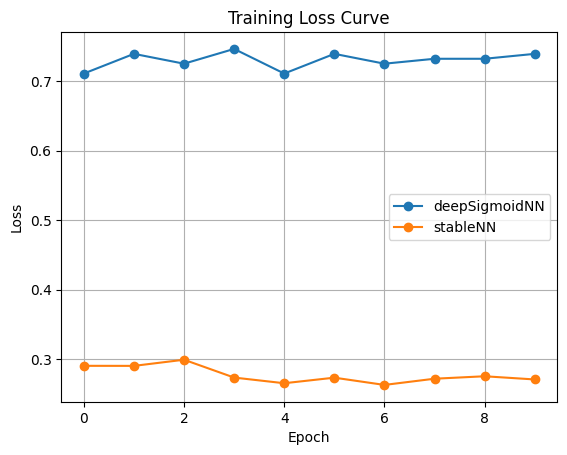

In [51]:
# visualize loss curve on training
plt.plot(loss_log01, marker='o', label='deepSigmoidNN')
plt.plot(loss_log02, marker='o', label='stableNN')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.legend()
plt.grid()
plt.show()

In [53]:
# fumction to visualize Gradient flow across layers
def compare_gradients(grad_log1, grad_log2, label1, label2):
    g1 = np.array(grad_log1).mean(axis=0)
    g2 = np.array(grad_log2).mean(axis=0)

    plt.figure()
    plt.plot(g1, marker='o', label=label1)
    plt.plot(g2, marker='o', label=label2)

    plt.xlabel("Layer Index")
    plt.ylabel("Gradient Norm")
    plt.yscale("log")
    plt.title("Gradient Flow Comparison")
    plt.legend()
    plt.grid()
    plt.show()

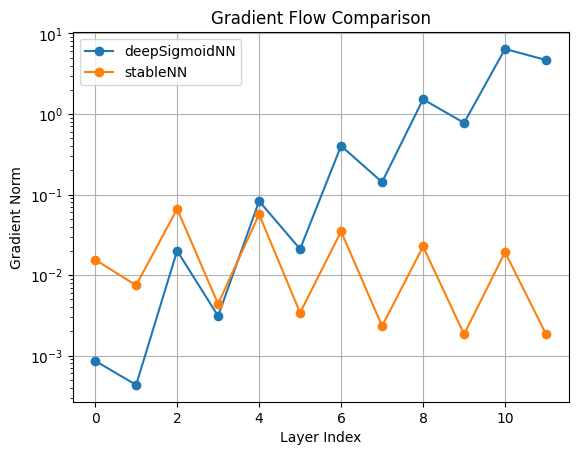

In [54]:
# visualize the flow
compare_gradients(grad_log01, grad_log02, 'deepSigmoidNN', 'stableNN')